# Spatial Copper Mining in DR Congo - Synthesis and Interpretation

## 4. Synthesis and Interpretation

This notebook closes the analytical loop by reading all processed outputs from notebooks I-III and asking the project's central question:

1. *What does the spatial and historical footprint of copper mining look like when read through open-source geodata* and 
2. *What does the landscape tell us about the relationship between geology, infrastructure, and environmental cost?*

**Inputs** (all pre-computed):

- `data/processed/mining_core/`  → `mrds_features.gpkg`, `mrds_clusters.gpkg`, `districts_mine_counts.gpkg`
- `data/processed/env_impact/`   → `ndvi_decline_zones.gpkg`, `drainage_network.gpkg`
- `data/processed/env_impact/`   → `spectral_indices.tif`, `ndvi_trend_2010_2025.tif`, `impact_score.tif`
- `data/raw/`                    → `srtm_copperbelt.tif`
- OneGeology / local ZIP geology loaded via `load_geology_from_local_zips()`

**Outputs**:

- `outputs/maps/synthesis/`  → publication-ready maps (one per section)
- `outputs/figures/synthesis/` → statistical figures and summary table
- `data/processed/synthesis/` → `synthesis_table.csv` (cluster × indicator matrix)



### Set up

In [129]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [130]:
from __future__ import annotations

import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LightSource
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import box
from adjustText import adjust_text

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from obtain_remote_data import (
    COPPERBELT_BBOX,
    CRS_PROJ,
    CRS_GEO,
    PROJECT_ROOT,
    DATA_RAW,
    DATA_PROCESSED,
    MAPS_OUT,
    FIGURES_OUT,
    load_full_copperbelt_admin,
    load_mrds,
    load_geology_from_local_zips,
)

from compute_data import (
    downsample_for_plot,
    extract_zonal_stats,
)

from mapstyle import (
    add_map_furniture, 
    add_panel_furniture,
    PALETTE
)

# Output directories
SYNTH_PROC  = DATA_PROCESSED / "synthesis"
MAPS_SYNTH  = MAPS_OUT / "synthesis"
FIGS_SYNTH  = FIGURES_OUT / "synthesis"

for _d in (SYNTH_PROC, MAPS_SYNTH, FIGS_SYNTH):
    _d.mkdir(parents=True, exist_ok=True)

# Projected bbox limits (from notebook II — manually adjusted for study area)
XMIN, YMIN, XMAX, YMAX = 190_000, 8_490_000, 760_000, 8_890_000

print("✓ Setup complete.")
print(f"  CRS_PROJ: {CRS_PROJ}")
print(f"  COPPERBELT_BBOX: {COPPERBELT_BBOX}")

✓ Setup complete.
  CRS_PROJ: EPSG:32735
  COPPERBELT_BBOX: [24.0, -13.7, 29.4, -10.0]


### Load all processed inputs

In [5]:
# ── Vector layers ────────────────────────────────────────────────────────────

# Mining core (notebook II)
MINING_DIR = DATA_PROCESSED / "mining_core"
mrds      = gpd.read_file(MINING_DIR / "mrds_features.gpkg").to_crs(CRS_PROJ)
clusters  = gpd.read_file(MINING_DIR / "mrds_clusters.gpkg").to_crs(CRS_PROJ)
districts = gpd.read_file(MINING_DIR / "districts_mine_counts.gpkg").to_crs(CRS_PROJ)

# Environmental impact (notebook III)
ENV_DIR = DATA_PROCESSED / "env_impact"
decline_zones   = gpd.read_file(ENV_DIR / "ndvi_decline_zones.gpkg").to_crs(CRS_PROJ)
drainage        = gpd.read_file(ENV_DIR / "drainage_network.gpkg").to_crs(CRS_PROJ)

# Administrative — admin boundaries + country polygons
districts_all = load_full_copperbelt_admin(COPPERBELT_BBOX, level=2)
countries     = districts_all.dissolve(by="GID_0")
rdc           = countries.loc[["COD"]].geometry.values[0]
zambia        = countries.loc[["ZMB"]].geometry.values[0]
boundary      = rdc.intersection(zambia)

print(f"  mrds:         {len(mrds):,} mine occurrences")
print(f"  clusters:     {len(clusters['cluster'].unique())} distinct clusters")
print(f"  districts:    {len(districts):,} administrative units")
print(f"  decline_zones:{len(decline_zones):,} NDVI decline polygons")


  GADM — downloading COD level 2...
    COD: 13 units loaded.
  GADM — downloading ZMB level 2...
    ZMB: 31 units loaded.
  mrds:         132 mine occurrences
  clusters:     6 distinct clusters
  districts:    44 administrative units
  decline_zones:2,103 NDVI decline polygons


In [6]:
# ── Rasters ──────────────────────────────────────────────────────────────────

# Sentinel-2 spectral indices (notebook III)
env_indices_path = ENV_DIR / "spectral_indices.tif"
env_indices = rxr.open_rasterio(env_indices_path, masked=True) if env_indices_path.exists() else None

# MODIS NDVI trend (notebook III)
ndvi_trend_path = ENV_DIR / "ndvi_trend_2010_2025.tif"
ndvi_trend = rxr.open_rasterio(ndvi_trend_path, masked=True).squeeze() if ndvi_trend_path.exists() else None

# Composite impact score (notebook III)
impact_path = ENV_DIR / "impact_score.tif"
impact_score = rxr.open_rasterio(impact_path, masked=True).squeeze() if impact_path.exists() else None

# SRTM DEM
srtm_path = DATA_RAW / "srtm_copperbelt.tif"
dem = rxr.open_rasterio(srtm_path, masked=True).squeeze().rio.reproject(CRS_PROJ) if srtm_path.exists() else None

# Geology
geo = load_geology_from_local_zips(COPPERBELT_BBOX)
geo = geo.clip(box(*COPPERBELT_BBOX)).to_crs(CRS_PROJ)

print("✓ Rasters loaded.")
if ndvi_trend is not None:
    finite = ndvi_trend.values[np.isfinite(ndvi_trend.values)]
    print(f"  NDVI trend slope range: {finite.min():.4f} - {finite.max():.4f} NDVI yr⁻¹")
if impact_score is not None:
    finite = impact_score.values[np.isfinite(impact_score.values)]
    print(f"  Impact score range:     {finite.min():.3f} - {finite.max():.3f}")


  Geology — reading local cache: geology_copperbelt.geojson
✓ Rasters loaded.
  NDVI trend slope range: -0.0620 - 0.0586 NDVI yr⁻¹
  Impact score range:     0.066 - 0.733


## 4.1 Geological substrate and mineralisation

The Katanga Copperbelt's copper-cobalt ore system is hosted in the **Roan Group** — a Neoproterozoic metasedimentary sequence (dolomites, shales, siltstones) that
constitutes the principal ore-bearing unit of the Copperbelt-type stratabound deposits.<br>

This section overlays the MRDS mine occurrences onto the OneGeology lithological units to quantify what proportion of recorded occurrences fall within Precambrian units, and whether the DBSCAN clusters respect the geology.<br>

Key questions:
- Do mine clusters align with Precambrian (Neoproterozoic) outcrops?
- Are "outlier" mines located in Cenozoic cover or undifferentiated units?
- What is the mine density (occurrences/km²) per lithological class?


In [41]:
# ── Prepare geology categories (reuse palette from notebook I) ───────────────

ORDERED_UNITS = [
    "Water (River or Lake)",
    "Holocene",
    "Quaternary (undivided)",
    "Cenozoic (undivided)",
    "Permian-Carboniferous",
    "Precambrian",
    "Undifferentiated",
]
GEO_COLORS = {
    "Water (River or Lake)":  "#1f78b4",
    "Holocene":               "#583f9b",
    "Quaternary (undivided)": "#66a61e",
    "Cenozoic (undivided)":   "#e3d615",
    "Permian-Carboniferous":  "#87784F",
    "Precambrian":            "#7f360e",
    "Undifferentiated":       "#999999",
}

geo["long_name"] = geo["long_name"].fillna("Undifferentiated").replace(
    {"Cenozoic": "Cenozoic (undivided)"}
)
geo["_plot_cat"] = geo["long_name"].where(
    geo["long_name"].isin(ORDERED_UNITS[:-1]), other="Undifferentiated"
)
geo["_color"] = geo["_plot_cat"].map(GEO_COLORS).fillna("#999999")

# ── Sort geology so Permian-Carboniferous renders BEFORE Precambrian ─────────
# Painting order matters: Undifferentiated base first, Precambrian (ore unit) last.
_unit_order = {u: i for i, u in enumerate(ORDERED_UNITS)}
geo["_sort_key"] = geo["_plot_cat"].map(_unit_order).fillna(len(ORDERED_UNITS))
geo = geo.sort_values("_sort_key").reset_index(drop=True)

# ── Spatial join: mines onto geology polygons ────────────────────────────────
# Primary join — within polygon
mrds_geo = gpd.sjoin(mrds, geo[["_plot_cat", "geometry"]], how="left", predicate="within")

# Fallback for points on polygon boundaries or gaps — nearest polygon
missing = mrds_geo["_plot_cat"].isna()
if missing.any():
    fallback = gpd.sjoin_nearest(
        mrds[missing][["geometry"]], geo[["_plot_cat", "geometry"]], how="left"
    )
    mrds_geo.loc[missing, "_plot_cat"] = fallback["_plot_cat"].values

mrds_geo["_plot_cat"] = mrds_geo["_plot_cat"].fillna("Undifferentiated")

geo_summary = (
    mrds_geo.groupby("_plot_cat")
    .size()
    .reset_index(name="n_mines")
    .assign(pct=lambda df: df["n_mines"] / df["n_mines"].sum() * 100)
    .sort_values("n_mines", ascending=False)
)

print("Mine occurrences by lithological unit:")
print(geo_summary.to_string(index=False))

Mine occurrences by lithological unit:
           _plot_cat  n_mines       pct
    Undifferentiated      132 50.000000
         Precambrian      131 49.621212
Cenozoic (undivided)        1  0.378788


In [44]:
# ── Mine density per lithological class (occurrences per 1000 km²) ──────────

geo_area = geo.groupby("_plot_cat")["geometry"].apply(
    lambda g: g.area.sum() / 1e6  # km²
).reset_index(name="area_km2")

geo_summary = geo_summary.merge(geo_area, on="_plot_cat", how="left")
geo_summary["density_per_1000km2"] = (
    geo_summary["n_mines"] / geo_summary["area_km2"] * 1000
).round(2)

print("\nMine density by lithological unit:")
print(geo_summary[["_plot_cat", "n_mines", "area_km2", "density_per_1000km2"]].to_string(index=False))



Mine density by lithological unit:
           _plot_cat  n_mines      area_km2  density_per_1000km2
    Undifferentiated      132 240838.874823                 0.55
         Precambrian      131 190184.272632                 0.69
Cenozoic (undivided)        1  41340.539926                 0.02


In [45]:
# ── Cluster IDs and colormap — defined here, reused throughout notebook ───────
cluster_ids   = sorted([c for c in clusters["cluster"].unique() if c != -1])
cmap_clusters = plt.cm.get_cmap("tab10", len(cluster_ids))

In [67]:
from mapstyle import add_panel_furniture

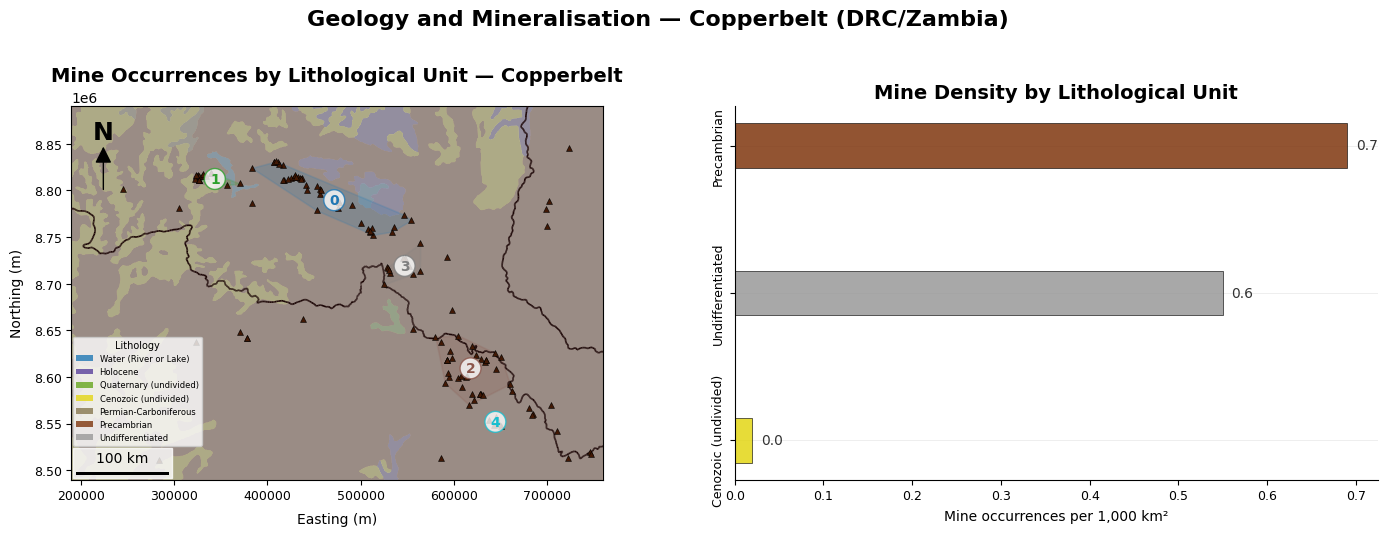

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# ── Left: geology + mines + clusters ────────────────────────────────────────
ax = axes[0]
geo.plot(ax=ax, color=geo["_color"], edgecolor="none", alpha=0.75)

gpd.GeoSeries([boundary], crs=CRS_GEO).to_crs(CRS_PROJ).plot(
    ax=ax, color="#1C0606", linewidth=1.2, linestyle="--", zorder=4,
)

for i, cid in enumerate(cluster_ids):
    pts = clusters[clusters["cluster"] == cid]
    if len(pts) < 3:
        continue
    hull = pts.unary_union.convex_hull
    gpd.GeoSeries([hull], crs=CRS_PROJ).plot(
        ax=ax, color=cmap_clusters(i), alpha=0.18, edgecolor=cmap_clusters(i),
        linewidth=1.2, zorder=3,
    )
    cx, cy = hull.centroid.x, hull.centroid.y
    ax.text(cx, cy, str(cid), fontsize=10, fontweight="bold",
            ha="center", va="center", color=cmap_clusters(i),
            bbox=dict(boxstyle="circle,pad=0.25", fc="white", ec=cmap_clusters(i), alpha=0.8),
            zorder=6)

mrds.plot(ax=ax, color="#421905", markersize=18, marker="^",
          edgecolor="black", linewidth=0.4, zorder=5, label="Mine occurrences")

geo_patches = [
    mpatches.Patch(facecolor=GEO_COLORS[u], edgecolor="none", label=u, alpha=0.8)
    for u in ORDERED_UNITS if u in geo["_plot_cat"].unique()
]
ax.legend(handles=geo_patches, title="Lithology", loc="lower left",
          bbox_to_anchor=(-0.005, 0.08), fontsize=6, title_fontsize=7,
          frameon=True)

ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
ax.axis("on")
add_map_furniture(ax, gdf_ref=mrds,
                  title="Mine Occurrences by Lithological Unit — Copperbelt",
                  legend=False)

# ── Right: bar chart — mine density per lithological unit ───────────────────
ax2 = axes[1]
plot_df = geo_summary.dropna(subset=["density_per_1000km2"]).sort_values(
    "density_per_1000km2", ascending=True
)
colors_bar = [GEO_COLORS.get(u, "#999999") for u in plot_df["_plot_cat"]]

y_pos = np.arange(len(plot_df))

bars = ax2.barh(
    y=y_pos,
    width=plot_df["density_per_1000km2"],
    height=0.3, color=colors_bar, edgecolor="black", 
    linewidth=0.5, alpha=0.85)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(plot_df["_plot_cat"], rotation=90, va="center", fontsize=10)

for bar, val in zip(bars, plot_df["density_per_1000km2"]):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}", va="center", fontsize=10, color="#333")

add_panel_furniture(
    ax2,
    title="Mine Density by Lithological Unit",
    xlabel="Mine occurrences per 1,000 km²",
    grid=True
)

plt.suptitle("Geology and Mineralisation — Copperbelt (DRC/Zambia)",
             fontsize=16, y=0.95, fontweight="bold")
plt.tight_layout()
plt.savefig(MAPS_SYNTH / "4_1_geology_mineralisation.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.2 Infrastructure accessibility gradient

Mining viability — and, historically, colonial extraction logistics — depends critically on transport infrastructure. This section asks:

- Is there a measurable **distance gradient**: do mine clusters closest to primary roads also show higher mine density?
- Do mines near the DRC-Zambia border form a spatial corridor, reflecting the shared Copperbelt geology that crosses the political boundary?
- Which DBSCAN clusters are most "stranded" (high median distance to road)?

Data: `dist_road_km`, `dist_border_km` columns in `mrds_features.gpkg`.


In [80]:
# ── Cluster-level infrastructure summary ────────────────────────────────────

# Attach cluster ID to mrds_features via spatial join
mrds_with_cluster = gpd.sjoin_nearest(
    mrds[["site_name", "ore_map", "dist_road_km", "dist_water_km",
          "dist_border_km", "geometry"]],
    clusters[["cluster", "geometry"]],
    how="left",
    distance_col="_join_dist",
)

cluster_infra = (
    mrds_with_cluster[mrds_with_cluster["cluster"] != -1]
    .groupby("cluster")
    .agg(
        n_mines            = ("site_name",     "count"),
        median_dist_road   = ("dist_road_km",   "median"),
        median_dist_water  = ("dist_water_km",  "median"),
        median_dist_border = ("dist_border_km", "median"),
    )
    .reset_index()
    .sort_values("cluster")
)

print("Cluster accessibility (median distances in km):")
print(cluster_infra.to_string(index=False))


Cluster accessibility (median distances in km):
 cluster  n_mines  median_dist_road  median_dist_water  median_dist_border
       0       42        176.053373           1.197104           95.516327
       1       18        204.739213           1.769657           53.823065
       2       39          9.171469           1.484623           24.375406
       3       11        136.065303           2.735125           24.018415
       4        5         13.288652           0.925363           30.814685


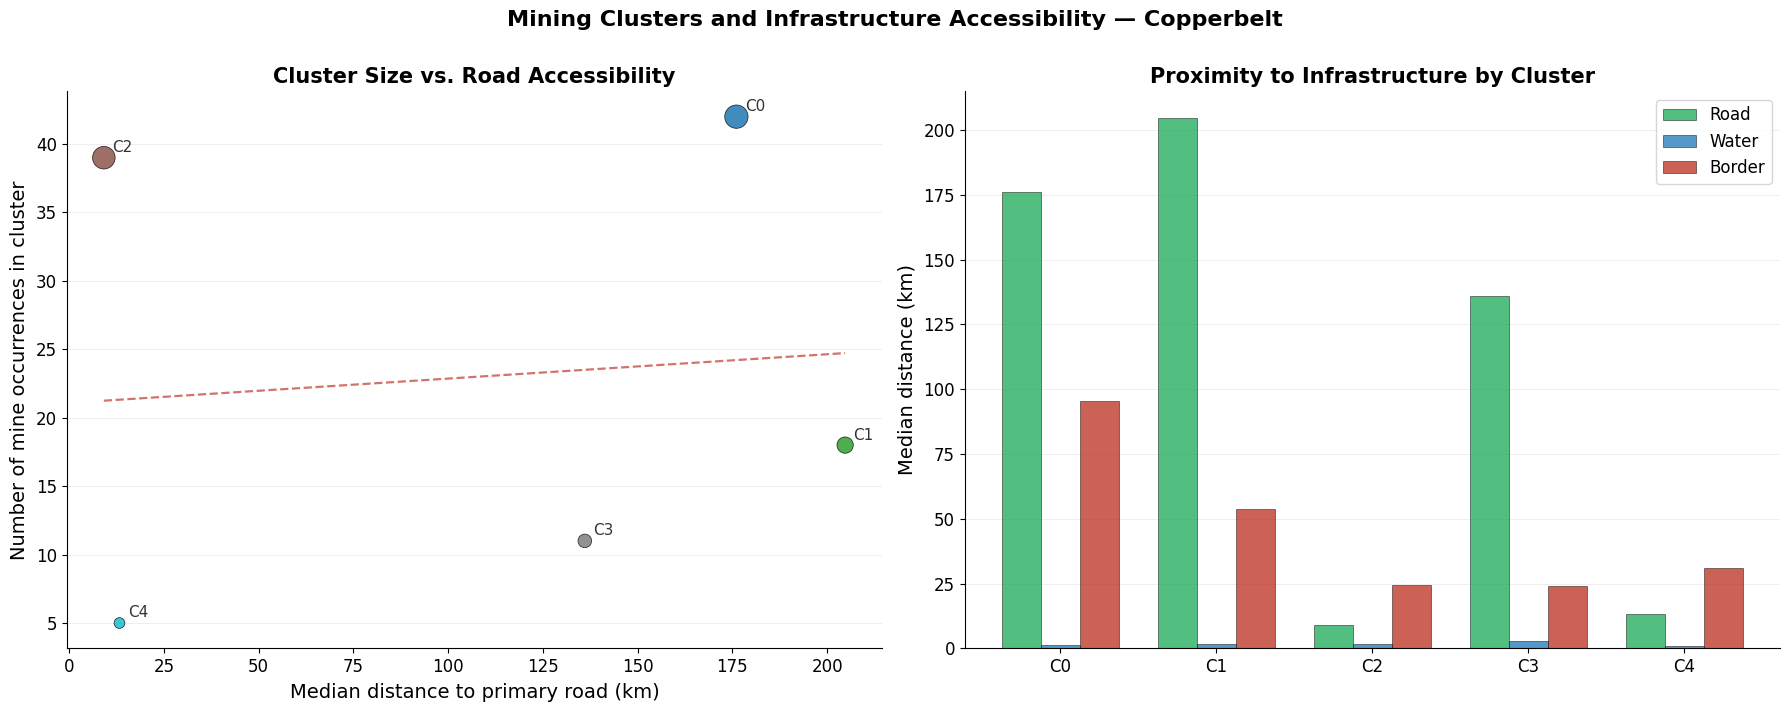

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: scatter — mine count vs. median road distance per cluster ──────────
ax = axes[0]
scatter_colors = [cmap_clusters(cluster_ids.index(c)) if c in cluster_ids else "#aaa"
                  for c in cluster_infra["cluster"]]

sc = ax.scatter(
    cluster_infra["median_dist_road"],
    cluster_infra["n_mines"],
    c=scatter_colors,
    s=cluster_infra["n_mines"] * 6 + 30,
    edgecolors="black", linewidth=0.5, alpha=0.85, zorder=3,
)

for _, row in cluster_infra.iterrows():
    ax.annotate(f"C{int(row['cluster'])}",
                (row["median_dist_road"], row["n_mines"]),
                xytext=(6, 4), textcoords="offset points",
                fontsize=11, color="#333")

# Trend line
if len(cluster_infra) > 2:
    m, b_coef = np.polyfit(cluster_infra["median_dist_road"], cluster_infra["n_mines"], 1)
    xs = np.linspace(cluster_infra["median_dist_road"].min(),
                     cluster_infra["median_dist_road"].max(), 100)
    ax.plot(xs, m * xs + b_coef, color="#c0392b", linewidth=1.6, linestyle="--", alpha=0.7)

ax.spines[["top", "right"]].set_visible(False)

add_panel_furniture(
    ax,
    title="Cluster Size vs. Road Accessibility",
    xlabel="Median distance to primary road (km)",
    ylabel="Number of mine occurrences in cluster",
    legend=True,
    legend_loc="upper right", title_fontsize=15,
    grid=True, legend_fontsize=12, label_fontsize=14,
)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

# ── Right: grouped bar — road / water / border distances per cluster ─────────
ax2 = axes[1]
x = np.arange(len(cluster_infra))
w = 0.25
cols = ["median_dist_road", "median_dist_water", "median_dist_border"]
lbls = ["Road", "Water", "Border"]
bar_cols = ["#27ae60", "#2980b9", "#c0392b"]

for i, (col, lbl, clr) in enumerate(zip(cols, lbls, bar_cols)):
    ax2.bar(x + i * w, cluster_infra[col], width=w, label=lbl,
            color=clr, alpha=0.8, edgecolor="black", linewidth=0.4)

ax2.set_xticks(x + w)
ax2.set_xticklabels([f"C{int(c)}" for c in cluster_infra["cluster"]], fontsize=11)

add_panel_furniture(
    ax2,
    title="Proximity to Infrastructure by Cluster",
    ylabel="Median distance (km)",
    legend=True,
    legend_loc="upper right", title_fontsize=15,
    grid=True, legend_fontsize=12, label_fontsize=14,
)
ax2.tick_params(axis="x", labelsize=12)
ax2.tick_params(axis="y", labelsize=12)

plt.suptitle("Mining Clusters and Infrastructure Accessibility — Copperbelt",
             fontsize=16, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_SYNTH / "4_2_cluster_infrastructure.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.3 Environmental footprint per mining cluster

Each DBSCAN cluster represents a spatial concentration of mine occurrences.<br>

Using zonal statistics (5 km buffer per mine point), we extract the mean environmental impact score within each cluster's catchment area.

This lets us ask:
- Which cluster has the highest composite environmental degradation signal?
- Is there a correlation between cluster size (n mines) and environmental impact?
- Do the Sentinel-2 NBR and NDVI readings corroborate the composite score?

The MODIS NDVI trend adds a long-term temporal dimension: persistent decline (< −0.003 NDVI yr⁻¹) indicates cumulative vegetation loss, not just a snapshot.


In [24]:
# ── Zonal stats: impact score per mine point ─────────────────────────────────

if impact_score is not None:
    mrds_env = extract_zonal_stats(
        mrds.to_crs(CRS_PROJ),
        impact_score,
        column_name="mean_impact",
        buffer_m=5_000,
    )
else:
    print("[WARN] Impact score raster not found — using placeholder zeros.")
    mrds_env = mrds.copy()
    mrds_env["mean_impact"] = np.nan

if ndvi_trend is not None:
    mrds_env = extract_zonal_stats(
        mrds_env,
        ndvi_trend,
        column_name="mean_ndvi_trend",
        buffer_m=5_000,
    )
else:
    mrds_env["mean_ndvi_trend"] = np.nan

# ── Aggregate to cluster level ───────────────────────────────────────────────

mrds_env_cluster = gpd.sjoin_nearest(
    mrds_env[["site_name", "mean_impact", "mean_ndvi_trend", "geometry"]],
    clusters[["cluster", "geometry"]],
    how="left",
    distance_col="_join_dist",
)

cluster_env = (
    mrds_env_cluster[mrds_env_cluster["cluster"] != -1]
    .groupby("cluster")
    .agg(
        n_mines          = ("site_name",       "count"),
        mean_impact      = ("mean_impact",      "mean"),
        mean_ndvi_trend  = ("mean_ndvi_trend",  "mean"),
    )
    .reset_index()
    .sort_values("mean_impact", ascending=False)
)

print("Environmental footprint by cluster:")
print(cluster_env.round(4).to_string(index=False))

  ✓ mean_impact: 132/132 features with valid values
  ✓ mean_ndvi_trend: 132/132 features with valid values
Environmental footprint by cluster:
 cluster  n_mines  mean_impact  mean_ndvi_trend
       1       18       0.3082          -0.0058
       3       11       0.2870          -0.0020
       2       39       0.2780           0.0025
       4        5       0.2776           0.0010
       0       42       0.2632          -0.0014


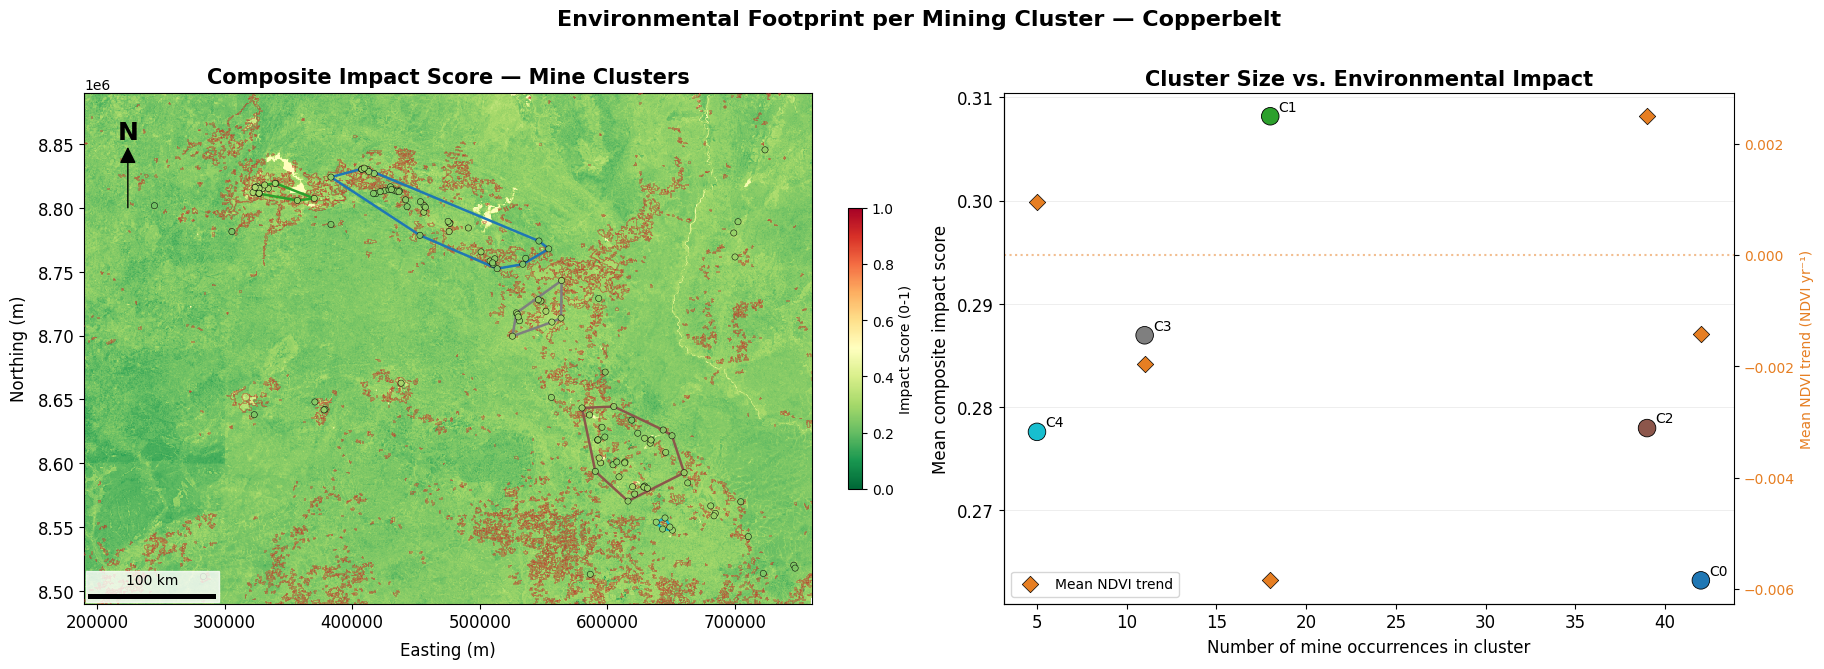

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# ── Left: map — impact score with cluster overlay ────────────────────────────
ax = axes[0]

if impact_score is not None:
    impact_plot = downsample_for_plot(impact_score, target_pixels=1000)
    impact_plot.plot(ax=ax, cmap="RdYlGn_r", vmin=0, vmax=1,
                     cbar_kwargs={"label": "Impact Score (0-1)", "shrink": 0.55})

for i, cid in enumerate(cluster_ids):
    pts = clusters[clusters["cluster"] == cid]
    if len(pts) < 3:
        continue
    hull = pts.unary_union.convex_hull
    gpd.GeoSeries([hull], crs=CRS_PROJ).plot(
        ax=ax, color="none", edgecolor=cmap_clusters(i), linewidth=1.8, zorder=4,
    )

mrds_env.plot(ax=ax, column="mean_impact", cmap="RdYlGn_r", vmin=0, vmax=1,
              markersize=20, edgecolor="black", linewidth=0.4, zorder=5, alpha=0.9)

if decline_zones is not None and len(decline_zones) > 0:
    decline_zones.boundary.plot(ax=ax, color="#c0392b", lw=0.5, alpha=0.6,
                                zorder=3, label="MODIS decline zones")

ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
ax.axis("on")
add_map_furniture(ax, gdf_ref=mrds,
                  title="Composite Impact Score — Mine Clusters",
                  legend=False, title_fontsize=15, label_fontsize=12, labelticksize=12,)

# ── Right: scatter — cluster size vs. mean impact ───────────────────────────
ax2 = axes[1]

colors_env = [cmap_clusters(cluster_ids.index(c)) if c in cluster_ids else "#aaa"
              for c in cluster_env["cluster"]]

ax2.scatter(
    cluster_env["n_mines"],
    cluster_env["mean_impact"],
    c=colors_env,
    s=160, edgecolors="black", linewidth=0.6, zorder=3,
)

# Secondary y-axis: NDVI trend
ax2b = ax2.twinx()
ax2b.scatter(
    cluster_env["n_mines"],
    cluster_env["mean_ndvi_trend"],
    marker="D", s=70, color="#e67e22", edgecolors="black",
    linewidth=0.5, zorder=4, label="Mean NDVI trend",
)
ax2b.axhline(0, color="#e67e22", linewidth=1.5, linestyle=":", alpha=0.5)
ax2b.set_ylabel("Mean NDVI trend (NDVI yr⁻¹)", fontsize=10, color="#e67e22")
ax2b.tick_params(axis="y", labelcolor="#e67e22")
ax2b.legend(loc="lower left", fontsize=10) 

for _, row in cluster_env.iterrows():
    ax2.annotate(f"C{int(row['cluster'])}",
                 (row["n_mines"], row["mean_impact"]),
                 xytext=(6, 4), textcoords="offset points", fontsize=10)

add_panel_furniture(
    ax2,
    title="Cluster Size vs. Environmental Impact",
    xlabel="Number of mine occurrences in cluster",
    ylabel="Mean composite impact score",
    grid=True, title_fontsize=15, label_fontsize=12, labelticksize=12,
)

plt.suptitle("Environmental Footprint per Mining Cluster — Copperbelt",
             fontsize=16, y=1.09, fontweight="bold")
plt.savefig(MAPS_SYNTH / "4_3_cluster_env_impact.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.4 Temporal signature — MODIS NDVI trend 2010-2025

The per-pixel OLS slope of annual NDVI composites captures **cumulative vegetation change** over 15 years at 250 m resolution — a longer signal than any single Sentinel-2 scene.

Questions:
- Which districts show the strongest sustained decline?
- Does the decline front match the expansion of mining activity observed in the DBSCAN clusters?
- Are there districts with *positive* trends — potential reforestation or reduced activity?

Method: aggregate the pixel-level trend into district-level medians and classify into five trend categories.

In [27]:
# ── District-level NDVI trend aggregation ───────────────────────────────────

if ndvi_trend is not None:
    districts_trend = extract_zonal_stats(
        districts.to_crs(CRS_PROJ),
        ndvi_trend,
        column_name="median_ndvi_trend",
        buffer_m=0,          # polygon extent, no extra buffer
    )
else:
    districts_trend = districts.copy()
    districts_trend["median_ndvi_trend"] = np.nan

# Classify trend categories
def classify_trend(val):
    if pd.isna(val):
        return "No data"
    elif val < -0.005:
        return "Strong decline  (< −0.005)"
    elif val < -0.002:
        return "Moderate decline  (−0.005 - −0.002)"
    elif val < 0.002:
        return "Stable  (±0.002)"
    elif val < 0.005:
        return "Moderate increase  (0.002 - 0.005)"
    else:
        return "Strong increase  (> 0.005)"

TREND_COLORS = {
    "Strong decline  (< −0.005)":            "#c0392b",
    "Moderate decline  (−0.005 - −0.002)":   "#e67e22",
    "Stable  (±0.002)":                       "#f1c40f",
    "Moderate increase  (0.002 - 0.005)":    "#2ecc71",
    "Strong increase  (> 0.005)":            "#27ae60",
    "No data":                                "#cccccc",
}

districts_trend["trend_class"] = districts_trend["median_ndvi_trend"].apply(classify_trend)
districts_trend["_color"]      = districts_trend["trend_class"].map(TREND_COLORS)

print("\nDistrict NDVI trend classification:")
print(districts_trend["trend_class"].value_counts().to_string())

# ──  Top 5 declining and improving districts ─────────────────────────────────
top_decline = districts_trend.nsmallest(5, "median_ndvi_trend")[["NAME_2", "median_ndvi_trend"]]
top_improve = districts_trend.nlargest(5, "median_ndvi_trend")[["NAME_2", "median_ndvi_trend"]]
print("\nTop 5 declining districts:")
print(top_decline.round(5).to_string(index=False))
print("\nTop 5 improving districts:")
print(top_improve.round(5).to_string(index=False))

  ✓ median_ndvi_trend: 44/44 features with valid values

District NDVI trend classification:
trend_class
Stable  (±0.002)                       28
Moderate increase  (0.002 - 0.005)     14
Strong decline  (< −0.005)              1
Moderate decline  (−0.005 - −0.002)     1

Top 5 declining districts:
       NAME_2  median_ndvi_trend
      Kolwezi           -0.00922
       Ngabwe           -0.00473
   Lubumbashi           -0.00144
Kapiri Mposhi           -0.00009
      Mpongwe           -0.00001

Top 5 improving districts:
   NAME_2  median_ndvi_trend
  Mitwaba            0.00414
Kalulushi            0.00362
    Kitwe            0.00329
 Mufulira            0.00324
    Ndola            0.00304


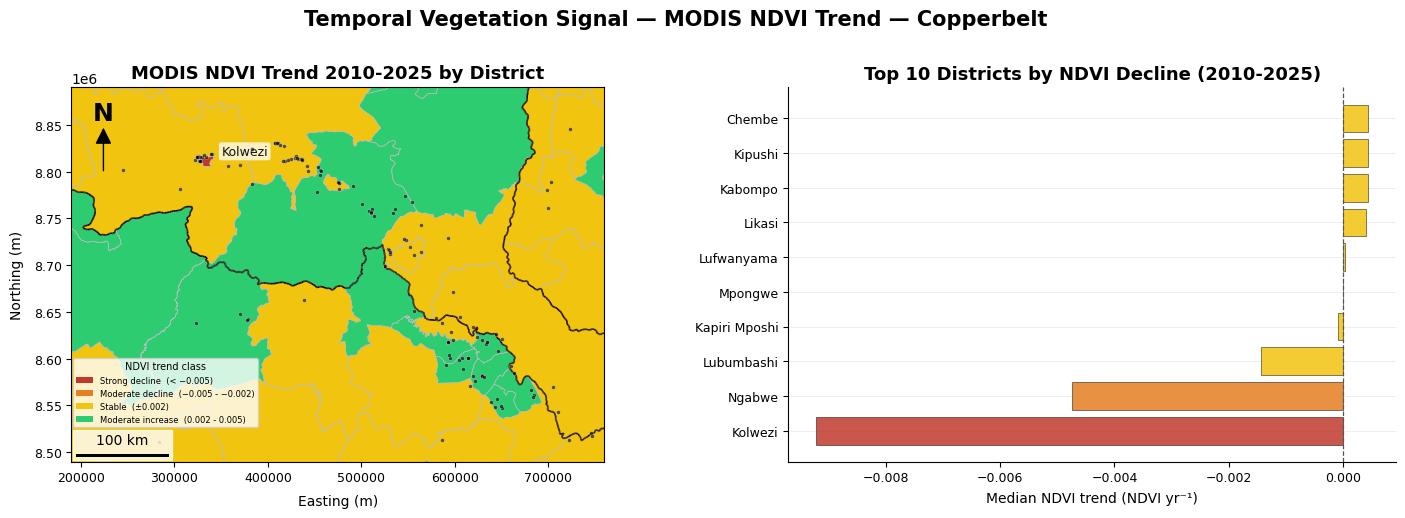

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# ── Left: district choropleth — trend class ──────────────────────────────────
ax = axes[0]
districts_trend.plot(ax=ax, color=districts_trend["_color"],
                     edgecolor="#bcbcbc", linewidth=0.5)

gpd.GeoSeries([boundary], crs=CRS_GEO).to_crs(CRS_PROJ).plot(
    ax=ax, color="#1C0606", linewidth=1.2, linestyle="--", zorder=4,
)
mrds.plot(ax=ax, color="black", markersize=8, edgecolor="white",
          linewidth=0.3, alpha=0.6, zorder=5, label="Mine occurrences")

# District labels for strongly declining districts
texts = []
for _, row in districts_trend[
    districts_trend["trend_class"].str.startswith("Strong decline")
].iterrows():
    x, y = row.geometry.representative_point().coords[0]
    texts.append(ax.text(x, y, row["NAME_2"], fontsize=9, color="#111",
                         bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75, ec="none")))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="black", lw=0.5))

trend_patches = [
    mpatches.Patch(facecolor=TREND_COLORS[k], label=k)
    for k in TREND_COLORS if k in districts_trend["trend_class"].unique()
]
ax.legend(handles=trend_patches, title="NDVI trend class",
          loc="lower left", bbox_to_anchor=(-0.005, 0.08),
          fontsize=6, title_fontsize=7, frameon=True)

ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
ax.axis("on")
add_map_furniture(ax, gdf_ref=mrds,
                  title="MODIS NDVI Trend 2010-2025 by District",
                  legend=False, title_fontsize=13)

# ── Right: bar chart — top 10 declining districts ────────────────────────────
ax2 = axes[1]
top10 = districts_trend.nsmallest(10, "median_ndvi_trend").sort_values("median_ndvi_trend")
bar_colors = [TREND_COLORS[c] for c in top10["trend_class"]]
bars = ax2.barh(top10["NAME_2"], top10["median_ndvi_trend"],
                color=bar_colors, edgecolor="black", linewidth=0.4, alpha=0.85)

add_panel_furniture(
    ax2,
    title="Top 10 Districts by NDVI Decline (2010-2025)",
    xlabel="Median NDVI trend (NDVI yr⁻¹)",
    zero_line="x",
    grid=True, title_fontsize=13
)

plt.suptitle("Temporal Vegetation Signal — MODIS NDVI Trend — Copperbelt",
             fontsize=15, y=0.92, fontweight="bold")
plt.tight_layout()
plt.savefig(MAPS_SYNTH / "4_4_ndvi_trend_districts.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.5 Synthesis — multi-axis summary table and composite map

This section assembles the cluster-level indicators computed in 4.1-4.4 into a single **synthesis table** and a **composite map** that expresses all analytical axes simultaneously:

- | Cluster | n mines | Dominant geology | Median dist road (km) |
- | Mean impact score | Mean NDVI trend (NDVI yr⁻¹) |

The composite map uses:
- **Background**: MODIS NDVI trend (green-red)
- **Overlays**: cluster hulls, decline zone boundaries, mine points sized by impact score
- **Inset table**: top-5 clusters by impact score

Together these layers answer the project question: the spatial footprint of copper mining is not random — it is shaped by the Precambrian ore-bearing geology, channelled by colonial-era infrastructure, and leaves a measurable signature in vegetation loss that persists decades after extraction.


In [30]:
# ── Build synthesis table ────────────────────────────────────────────────────

# Dominant geology per cluster (most common _plot_cat among mines in cluster)
mrds_geo_cluster = gpd.sjoin_nearest(
    mrds_geo[["site_name", "_plot_cat", "geometry"]],
    clusters[["cluster", "geometry"]],
    how="left",
    distance_col="_join_dist",
)

dominant_geo = (
    mrds_geo_cluster[mrds_geo_cluster["cluster"] != -1]
    .groupby("cluster")["_plot_cat"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index(name="dominant_geology")
)

synthesis = (
    cluster_infra
    .merge(cluster_env[["cluster", "mean_impact", "mean_ndvi_trend"]], on="cluster", how="left")
    .merge(dominant_geo, on="cluster", how="left")
    [[
        "cluster", "n_mines", "dominant_geology",
        "median_dist_road", "median_dist_border",
        "mean_impact", "mean_ndvi_trend",
    ]]
    .sort_values("mean_impact", ascending=False)
    .round({"median_dist_road": 1, "median_dist_border": 1,
            "mean_impact": 3, "mean_ndvi_trend": 5})
)

print("=" * 80)
print("SYNTHESIS TABLE — Cluster-level indicators")
print("=" * 80)
print(synthesis.to_string(index=False))

synthesis.to_csv(SYNTH_PROC / "synthesis_table.csv", index=False)
print(f"\n✓ Saved to {SYNTH_PROC / 'synthesis_table.csv'}")

SYNTHESIS TABLE — Cluster-level indicators
 cluster  n_mines dominant_geology  median_dist_road  median_dist_border  mean_impact  mean_ndvi_trend
       1       18      Precambrian             204.7                53.8        0.308         -0.00585
       3       11      Precambrian             136.1                24.0        0.287         -0.00195
       2       39      Precambrian               9.2                24.4        0.278          0.00250
       4        5      Precambrian              13.3                30.8        0.278          0.00096
       0       42      Precambrian             176.1                95.5        0.263         -0.00142

✓ Saved to C:\Users\jlima\Documents\GitHub\spatial-history-cuco-mining\data\processed\synthesis\synthesis_table.csv


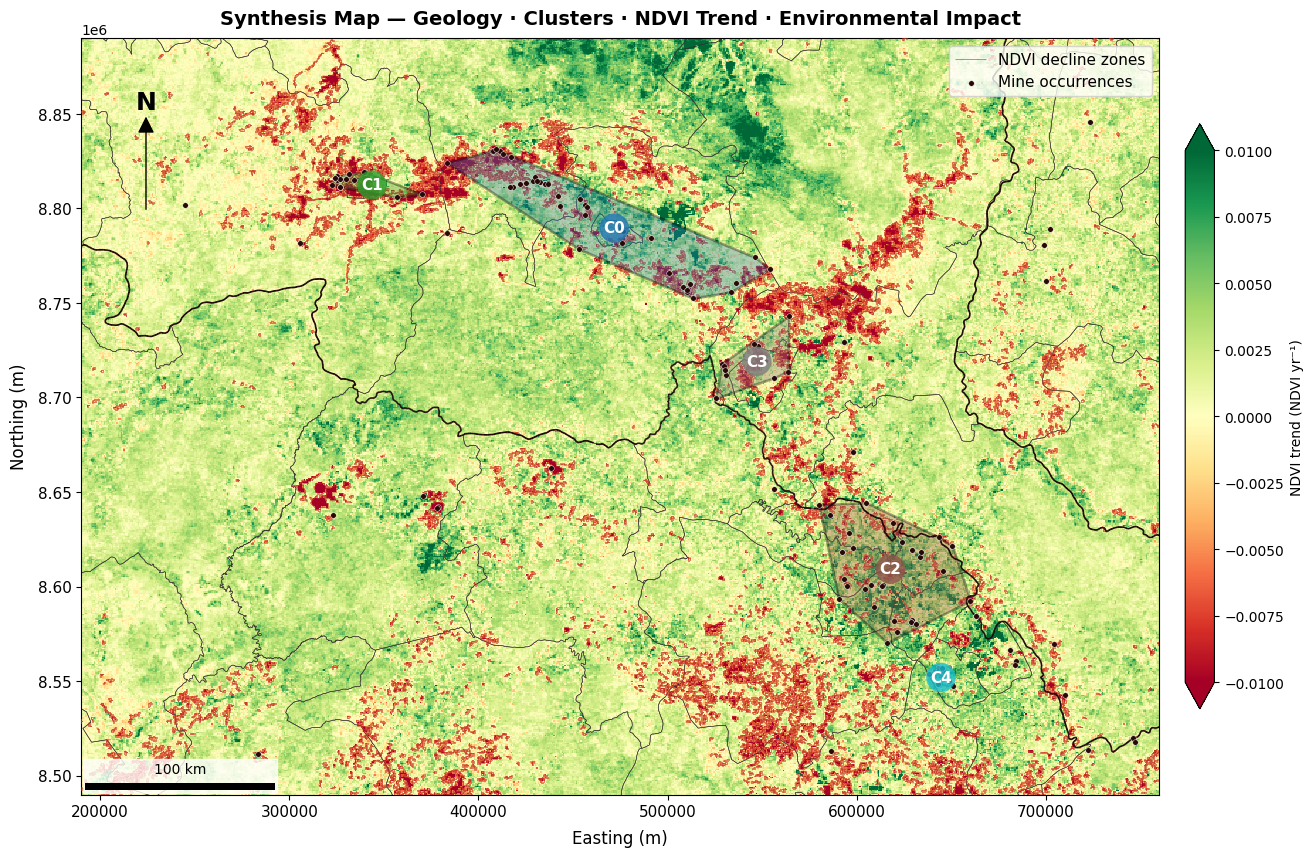

In [169]:
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111)

# Background: NDVI trend raster
if ndvi_trend is not None:
    trend_plot = downsample_for_plot(ndvi_trend, target_pixels=1000)
    trend_plot.plot(ax=ax, cmap="RdYlGn", vmin=-0.01, vmax=0.01,
                    cbar_kwargs={"label": "NDVI trend (NDVI yr⁻¹)", "shrink": 0.5,
                                 "pad": 0.02})

# District outlines (light, for orientation)
districts.to_crs(CRS_PROJ).plot(
    ax=ax, color="none", edgecolor="#383131", linewidth=0.4, zorder=2,
)

# International border
gpd.GeoSeries([boundary], crs=CRS_GEO).to_crs(CRS_PROJ).plot(
    ax=ax, color="#1C0606", linewidth=1.2, linestyle="--", zorder=5,
)

# MODIS decline zone boundaries
if decline_zones is not None and len(decline_zones) > 0:
    decline_zones.boundary.plot(
        ax=ax, color="#c0392b", lw=0.5, alpha=0.85, zorder=3,
        label="NDVI decline zones",
    )

# Cluster hulls (light fill) — collect centroids for labels rendered last
hull_centroids = []
for i, cid in enumerate(cluster_ids):
    pts = clusters[clusters["cluster"] == cid]
    if len(pts) < 3:
        continue
    hull       = pts.unary_union.convex_hull
    hull_color = cmap_clusters(i)
    gpd.GeoSeries([hull], crs=CRS_PROJ).plot(
        ax=ax, color=hull_color, alpha=0.35,
        edgecolor="black", linewidth=1.8, zorder=4,
    )
    hull_centroids.append((hull.centroid.x, hull.centroid.y, f"C{cid}", hull_color))

# Mine points — PALETTE["mine"], rendered above hulls (zorder=8)
mrds.plot(
    ax=ax, color=PALETTE["mine"], markersize=16,
    edgecolor="white", linewidth=0.3, zorder=8, label="Mine occurrences",
)

# Cluster labels — rendered last (zorder=10) so they sit above mine points
for cx, cy, label, color in hull_centroids:
    ax.text(cx, cy, label, fontsize=11, fontweight="bold",
            ha="center", va="center", color="white",
            bbox=dict(boxstyle="circle,pad=0.25", fc=color, ec="none", alpha=0.8),
            zorder=10)

ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
ax.axis("on")
add_map_furniture(
    ax, gdf_ref=mrds,
    title="Synthesis Map — Geology · Clusters · NDVI Trend · Environmental Impact",
    legend=True, label_fontsize=12, labelticksize=11
)

plt.tight_layout()
plt.savefig(MAPS_SYNTH / "4_5_synthesis_map.png", dpi=300, bbox_inches="tight")
plt.show()

Synthesis figure: 4-panel dashboard

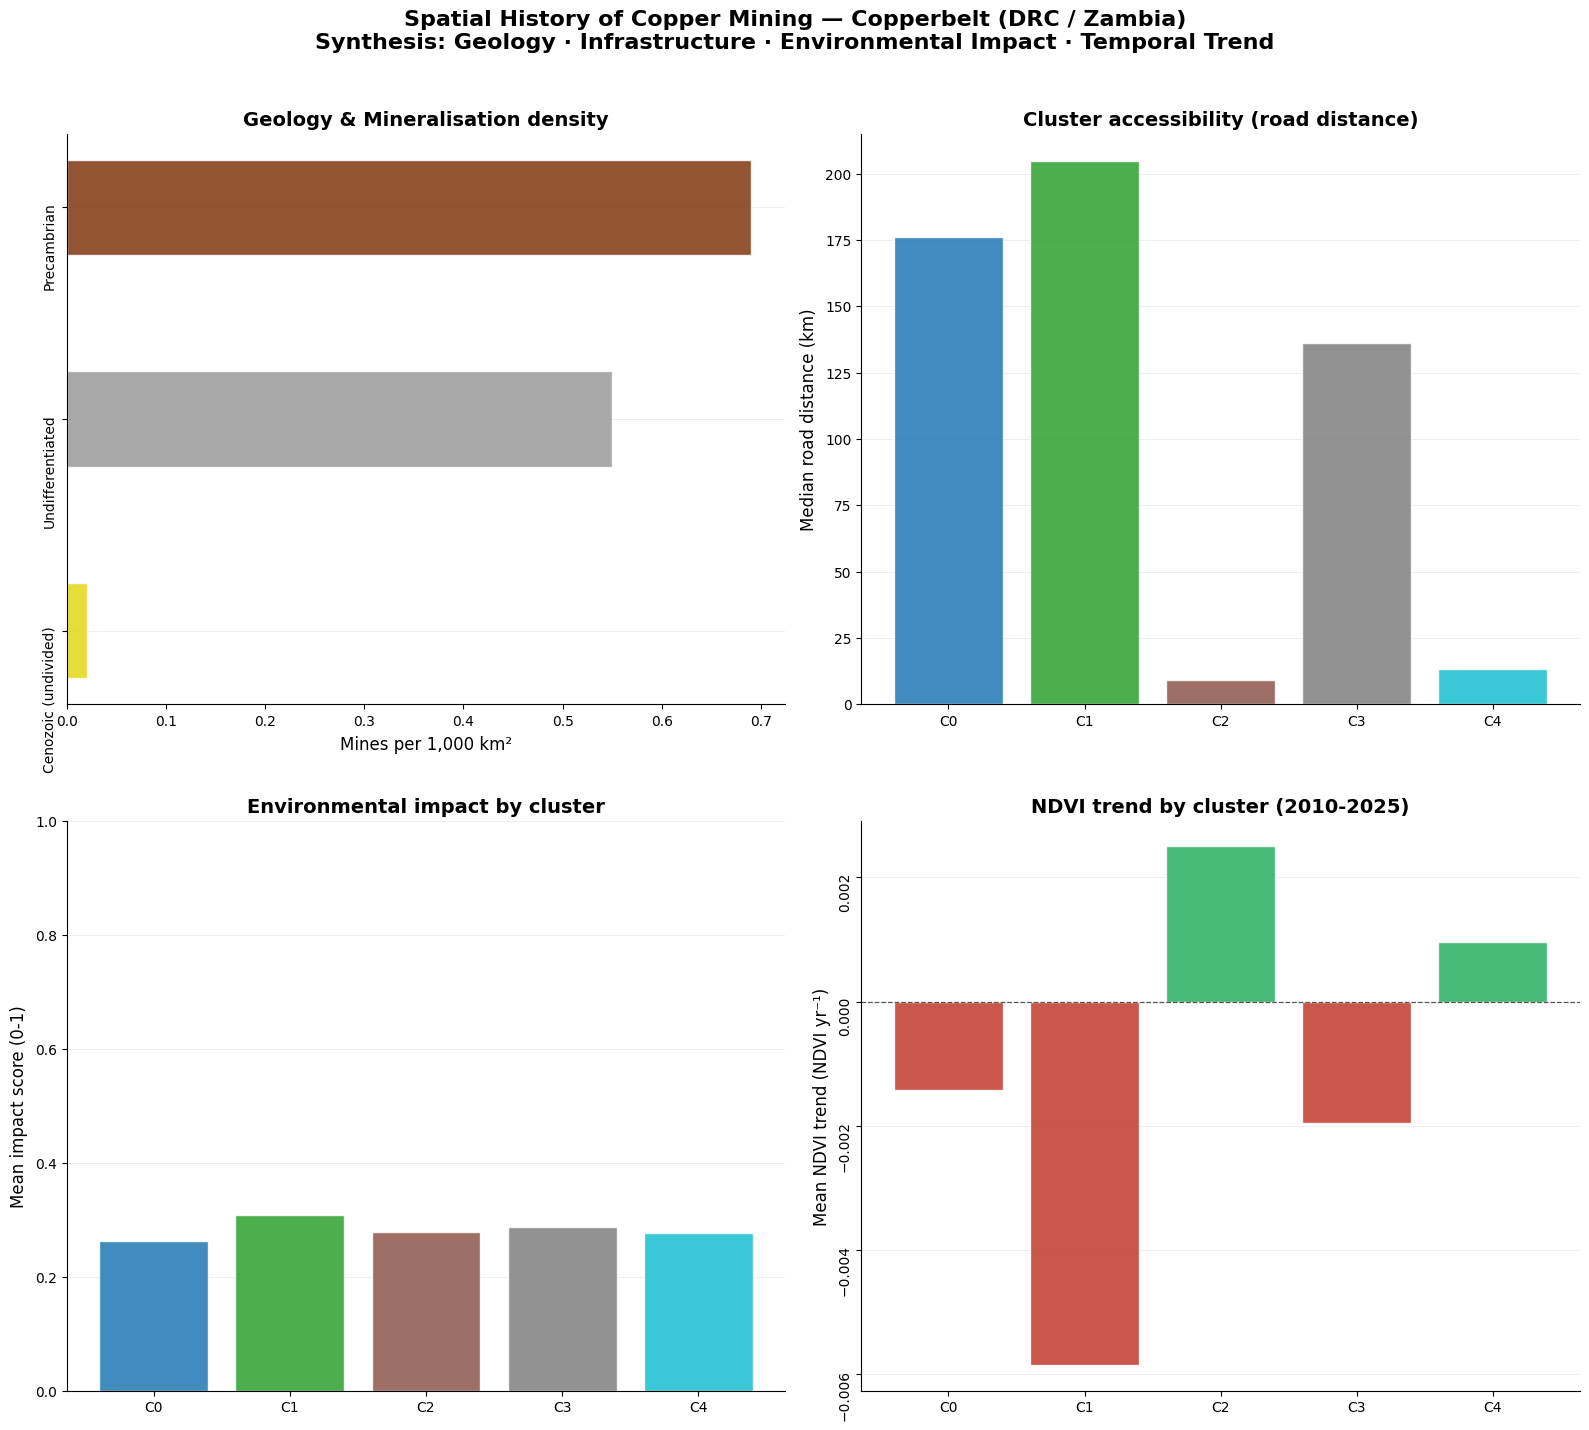

In [180]:
# Compact figure for presentation / README showing the four analytical axes.
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Panel 1: geology density (thin bars)
ax = axes[0, 0]
plot_df_s = geo_summary.dropna(subset=["density_per_1000km2"]).sort_values(
    "density_per_1000km2", ascending=True
)
ax.barh(plot_df_s["_plot_cat"], plot_df_s["density_per_1000km2"],
        height=0.45,
        color=[GEO_COLORS.get(u, "#999") for u in plot_df_s["_plot_cat"]],
        alpha=0.85, edgecolor="white")
ax.tick_params(axis="y", labelrotation=90)
add_panel_furniture(ax, title="Geology & Mineralisation density",
                    xlabel="Mines per 1,000 km²", grid=True, 
                    label_fontsize=12, labelticksize=10)

# Panel 2: road distance per cluster (ascending cluster ID)
ax = axes[0, 1]
_inf = cluster_infra.sort_values("cluster")
ax.bar(
    [f"C{int(c)}" for c in _inf["cluster"]],
    _inf["median_dist_road"],
    color=[cmap_clusters(cluster_ids.index(c)) if c in cluster_ids else "#aaa"
           for c in _inf["cluster"]],
    alpha=0.85, edgecolor="white",
)
add_panel_furniture(ax, title="Cluster accessibility (road distance)",
                    ylabel="Median road distance (km)", grid=True, 
                    label_fontsize=12, labelticksize=10)

# Panel 3: mean impact score per cluster (ascending cluster ID)
ax = axes[1, 0]
_env = cluster_env.sort_values("cluster")
ax.bar(
    [f"C{int(c)}" for c in _env["cluster"]],
    _env["mean_impact"],
    color=[cmap_clusters(cluster_ids.index(c)) if c in cluster_ids else "#aaa"
           for c in _env["cluster"]],
    alpha=0.85, edgecolor="white",
)
ax.set_ylim(0, 1)
add_panel_furniture(ax, title="Environmental impact by cluster",
                    ylabel="Mean impact score (0-1)", grid=True, 
                    label_fontsize=12, labelticksize=10)

# Panel 4: NDVI trend per cluster (ascending cluster ID)
ax = axes[1, 1]
ax.bar(
    [f"C{int(c)}" for c in _env["cluster"]],
    _env["mean_ndvi_trend"],
    color=["#c0392b" if v < 0 else "#27ae60"
           for v in _env["mean_ndvi_trend"].fillna(0)],
    alpha=0.85, edgecolor="white",
)
ax.tick_params(axis="y", labelrotation=90)
add_panel_furniture(ax, title="NDVI trend by cluster (2010-2025)",
                    ylabel="Mean NDVI trend (NDVI yr⁻¹)",
                    zero_line="y", grid=True, label_fontsize=12, labelticksize=10)

plt.suptitle(
    "Spatial History of Copper Mining — Copperbelt (DRC / Zambia)\n"
    "Synthesis: Geology · Infrastructure · Environmental Impact · Temporal Trend",
    fontsize=16, y=1.02, fontweight="bold",
)
plt.tight_layout()
plt.savefig(FIGS_SYNTH / "4_synthesis_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()
